In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Digital Life & Well-being: Predicting Stress from Screen Time and Sleep

## Introduction
In today's fast-paced digital world,our devices are constantly competing for our attention. But how does this affect our sleep and our stress levels?

In this notebook, we will explore a dataset about people's daily habits. We will look at how things like using a phone before bed, drinking coffee, and getting notifications affect our mental health. Our main goal is to find the hidden rules between our digital life and our stress.

## Project Objectives
This project is structured around two main goals:
1. **Exploratory Data Analysis (EDA):** To investigate the relationships between lifestyle choices (like phone usage before sleep, physical activity) and wellness indicators (mental fatigue, sleep duration).
2. **Predictive Modeling:** To build a **Multiple Linear Regression** model that predicts a user's `stress_level` based on their `daily_screen_time_hours` and `sleep_quality_score`, culminating in an intuitive 3D visualization of the regression plane.

## Dataset Overview
The dataset contains a rich set of behavioral and physiological features:
* **Digital Habits:** `daily_screen_time_hours`, `phone_usage_before_sleep_minutes`, `notifications_received_per_day`
* **Lifestyle Factors:** `caffeine_intake_cups`, `physical_activity_minutes`
* **Wellness Metrics:** `sleep_duration_hours`, `sleep_quality_score`, `stress_level` (Target), `mental_fatigue_score`



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'vscode'

In [3]:
df = pd.read_csv('/Users/elifceyhan/Desktop/stress-level-prediction/sleep_mobile_stress_dataset_15000.csv')

## Understanding Data

In [4]:
df.head(5)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [5]:
df.tail(5)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
14995,14996,39,Male,Manager,8.05,45,8.91,4.33,10.00,1,40,259,10.00
14996,14997,22,Female,Student,6.44,80,6.00,5.22,10.00,2,41,231,7.54
14997,14998,51,Female,Software Engineer,7.01,78,7.27,5.37,8.66,4,93,288,7.78
14998,14999,56,Female,Software Engineer,7.89,6,5.70,5.71,9.56,1,91,47,9.98
14999,15000,20,Female,Freelancer,6.05,93,4.74,5.04,9.33,0,117,64,9.26


In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

In [8]:
df.shape

(15000, 13)

In [9]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [10]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## EDA & Visualization

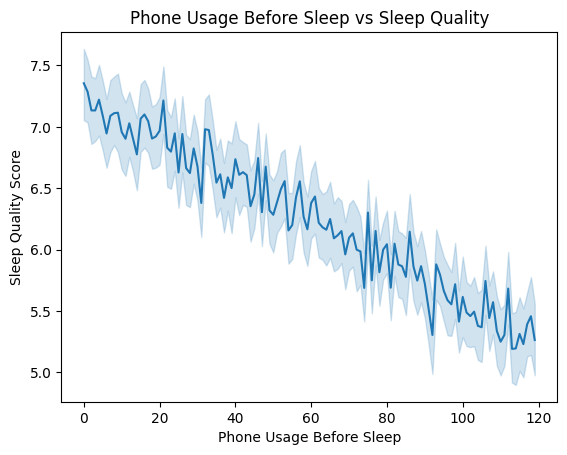

In [12]:
sns.lineplot(x="phone_usage_before_sleep_minutes",y="sleep_quality_score",data=df)
plt.xlabel("Phone Usage Before Sleep")
plt.ylabel("Sleep Quality Score")
plt.title("Phone Usage Before Sleep vs Sleep Quality")
plt.show()

As clearly illustrated in the line plot above, there is a strong negative correlationbetween phone usage before bed and sleep quality.

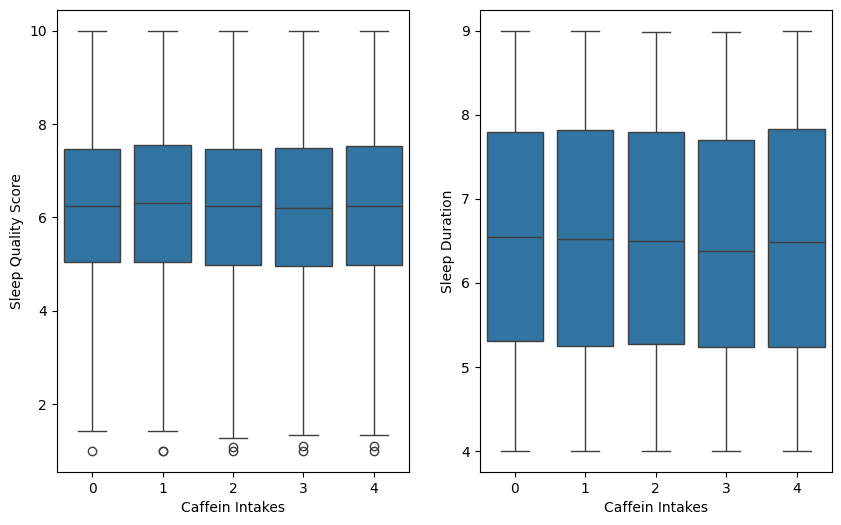

In [13]:
plt.figure(figsize=(10, 6)) 
plt.subplot(1,2,1)
sns.boxplot(x="caffeine_intake_cups", y="sleep_quality_score", data=df)
plt.xlabel("Caffein Intakes")
plt.ylabel("Sleep Quality Score")
plt.subplot(1,2,2)
sns.boxplot(x="caffeine_intake_cups", y="sleep_duration_hours", data=df)
plt.xlabel("Caffein Intakes")
plt.ylabel("Sleep Duration")
plt.show()


When we think about poor sleep,caffeine is usually the first suspect. However,these side-by-side boxplots reveal an unexpected pattern in our dataset:Caffeine intake seems to have almost no impact on sleep.

Insight: This is a fantastic reminder of why EDA is so important. We cannot always rely on general assumptions; the data shows us that for this specific group of users, other factors (like screen time) are clearly more dominant disrupters of sleep than their daily coffee.

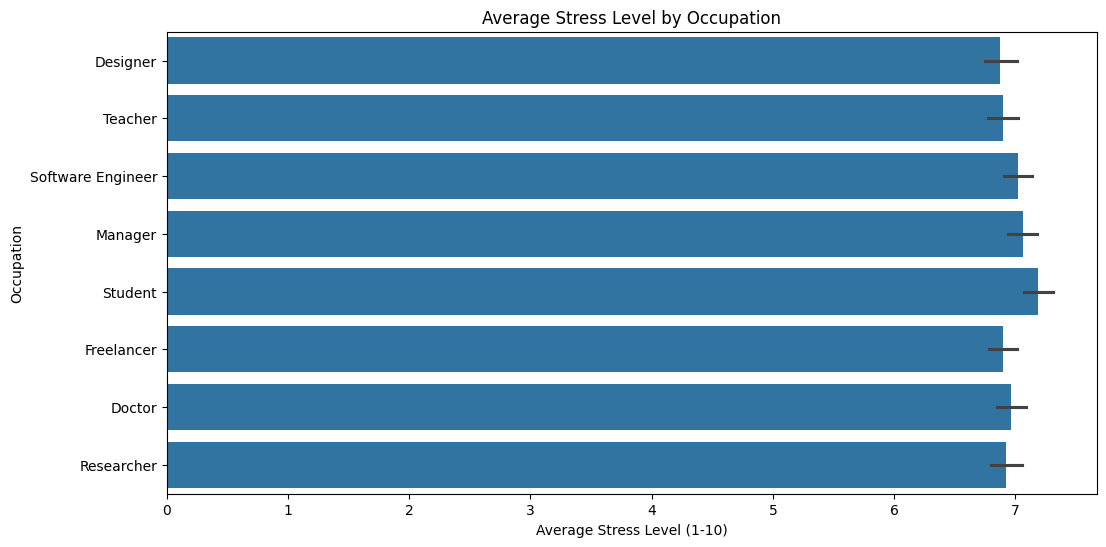

In [14]:
plt.figure(figsize=(12, 6))


sns.barplot(x="stress_level", y="occupation", data=df)

plt.title("Average Stress Level by Occupation")
plt.xlabel("Average Stress Level (1-10)")
plt.ylabel("Occupation")
plt.show()

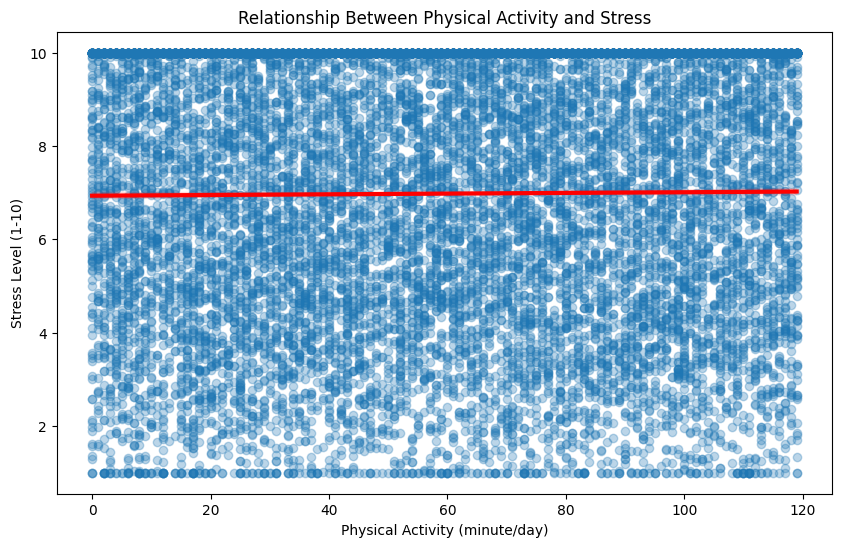

In [15]:
plt.figure(figsize=(10, 6))

sns.regplot(x="physical_activity_minutes", y="stress_level", data=df, 
            scatter_kws={'alpha':0.3}, 
            line_kws={'color':'red', 'linewidth':3})

plt.title("Relationship Between Physical Activity and Stress")
plt.xlabel("Physical Activity (minute/day)")
plt.ylabel("Stress Level (1-10)")
plt.show()

Just like the caffeine discovery, physical activity doesn't seem to be a major driving factor for stress in this specific dataset.

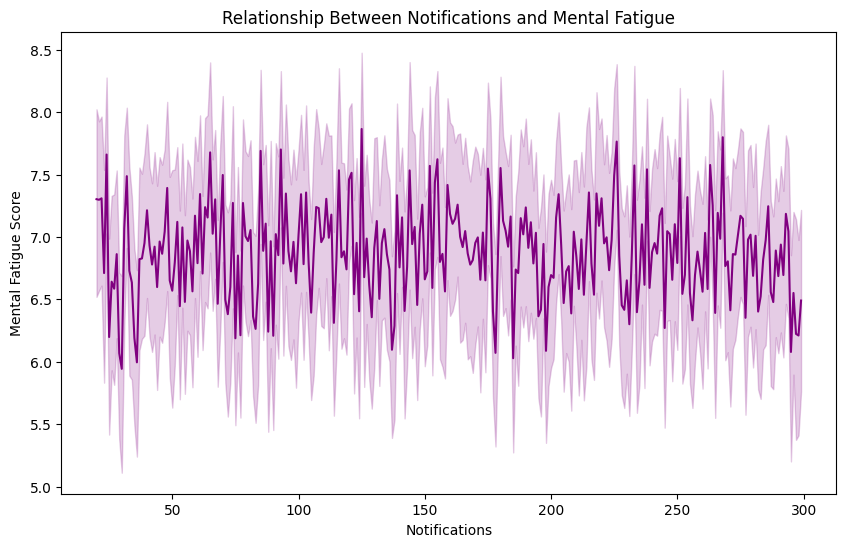

In [16]:
plt.figure(figsize=(10, 6))

sns.lineplot(x="notifications_received_per_day", y="mental_fatigue_score", data=df, color="purple")

plt.title("Relationship Between Notifications and Mental Fatigue")
plt.xlabel("Notifications")
plt.ylabel("Mental Fatigue Score")
plt.show()

Looking at this line plot, we might  expect higher notification counts to cause higher mental fatigue. However, the data displays a highly fluctuating and noisy relationship rather than a clear upward trend.

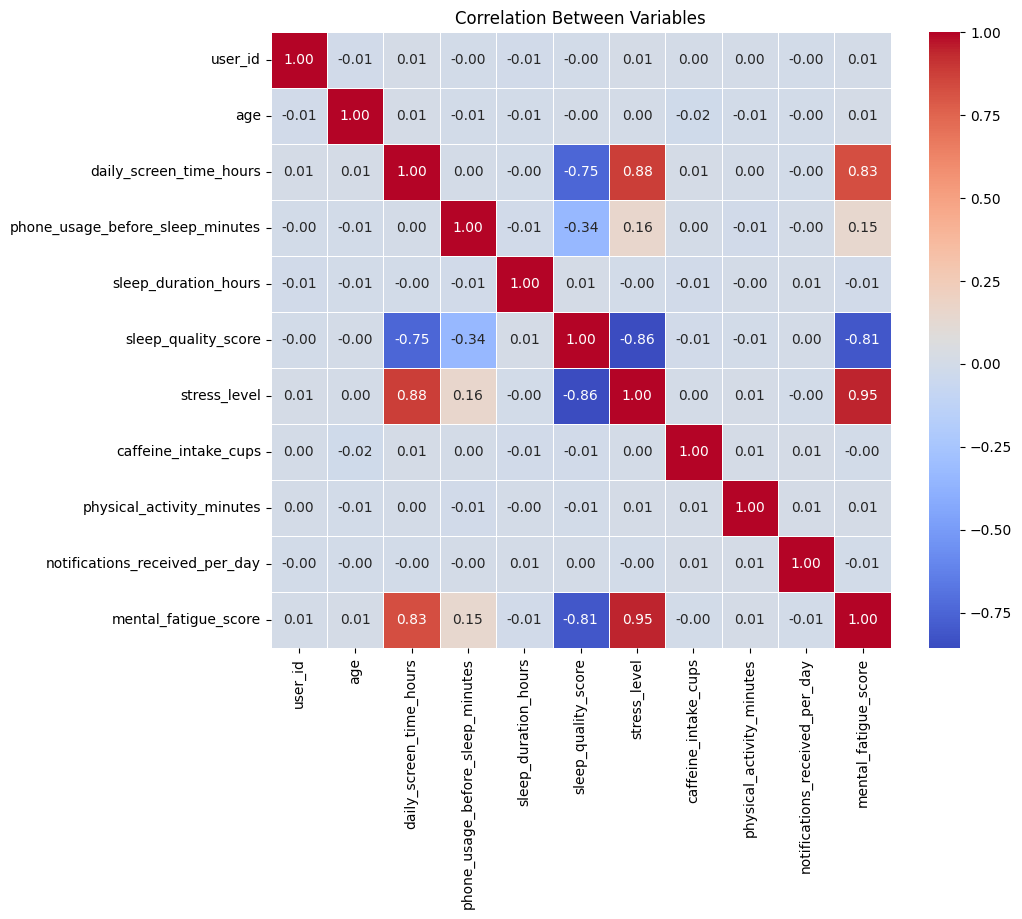

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Variables')
plt.show()

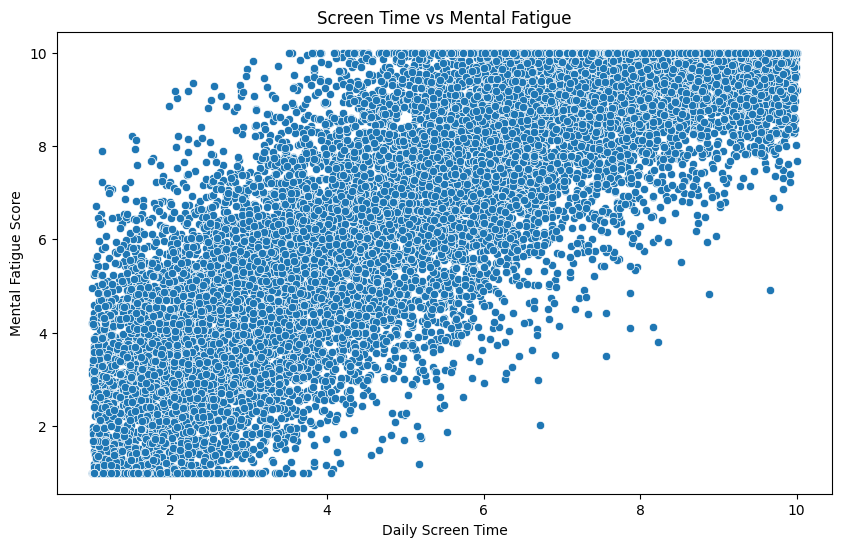

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="daily_screen_time_hours",y="mental_fatigue_score",data=df)
plt.title("Screen Time vs Mental Fatigue")
plt.xlabel("Daily Screen Time")
plt.ylabel("Mental Fatigue Score")
plt.show()




This scatter plot reveals a highly visible and strong **positive correlation** between daily screen time and mental fatigue.

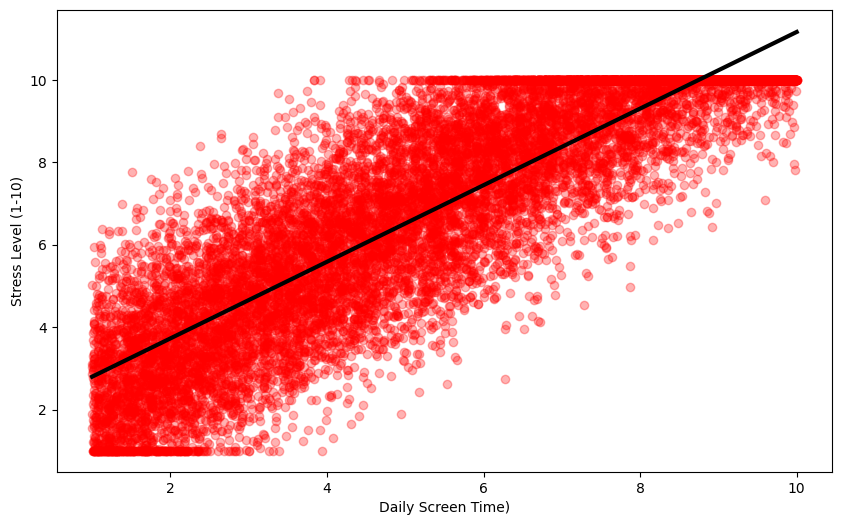

In [19]:
plt.figure(figsize=(10, 6)) 
sns.regplot(x="daily_screen_time_hours", y="stress_level", data=df, 
            scatter_kws={'alpha':0.3, 'color':'red'}, 
            line_kws={'color':'black', 'linewidth':3})

plt.xlabel("Daily Screen Time)")
plt.ylabel("Stress Level (1-10)")
plt.show() 

Just like mental fatigue, we see another undeniable trend here. This scatter plot shows a strong **positive correlation** between daily screen time and stress levels.

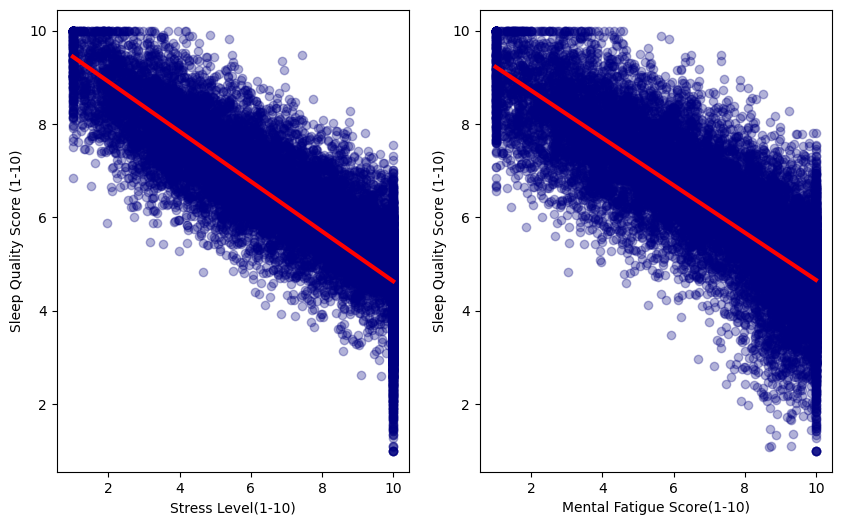

In [20]:
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
sns.regplot(x="stress_level", y="sleep_quality_score", data=df, 
            scatter_kws={'alpha':0.3, 'color':'navy'}, 
            line_kws={'color':'red', 'linewidth':3})
plt.xlabel("Stress Level(1-10)")
plt.ylabel("Sleep Quality Score (1-10)")

plt.subplot(1,2,2)
sns.regplot(x="mental_fatigue_score", y="sleep_quality_score", data=df, 
            scatter_kws={'alpha':0.3, 'color':'navy'}, 
            line_kws={'color':'red', 'linewidth':3})
plt.xlabel("Mental Fatigue Score(1-10)")
plt.ylabel("Sleep Quality Score (1-10)")

plt.show()

These scatter plots illustrate how stress and mental fatigue affect our sleep quality. In both cases, we can observe a clear **negative correlation**.

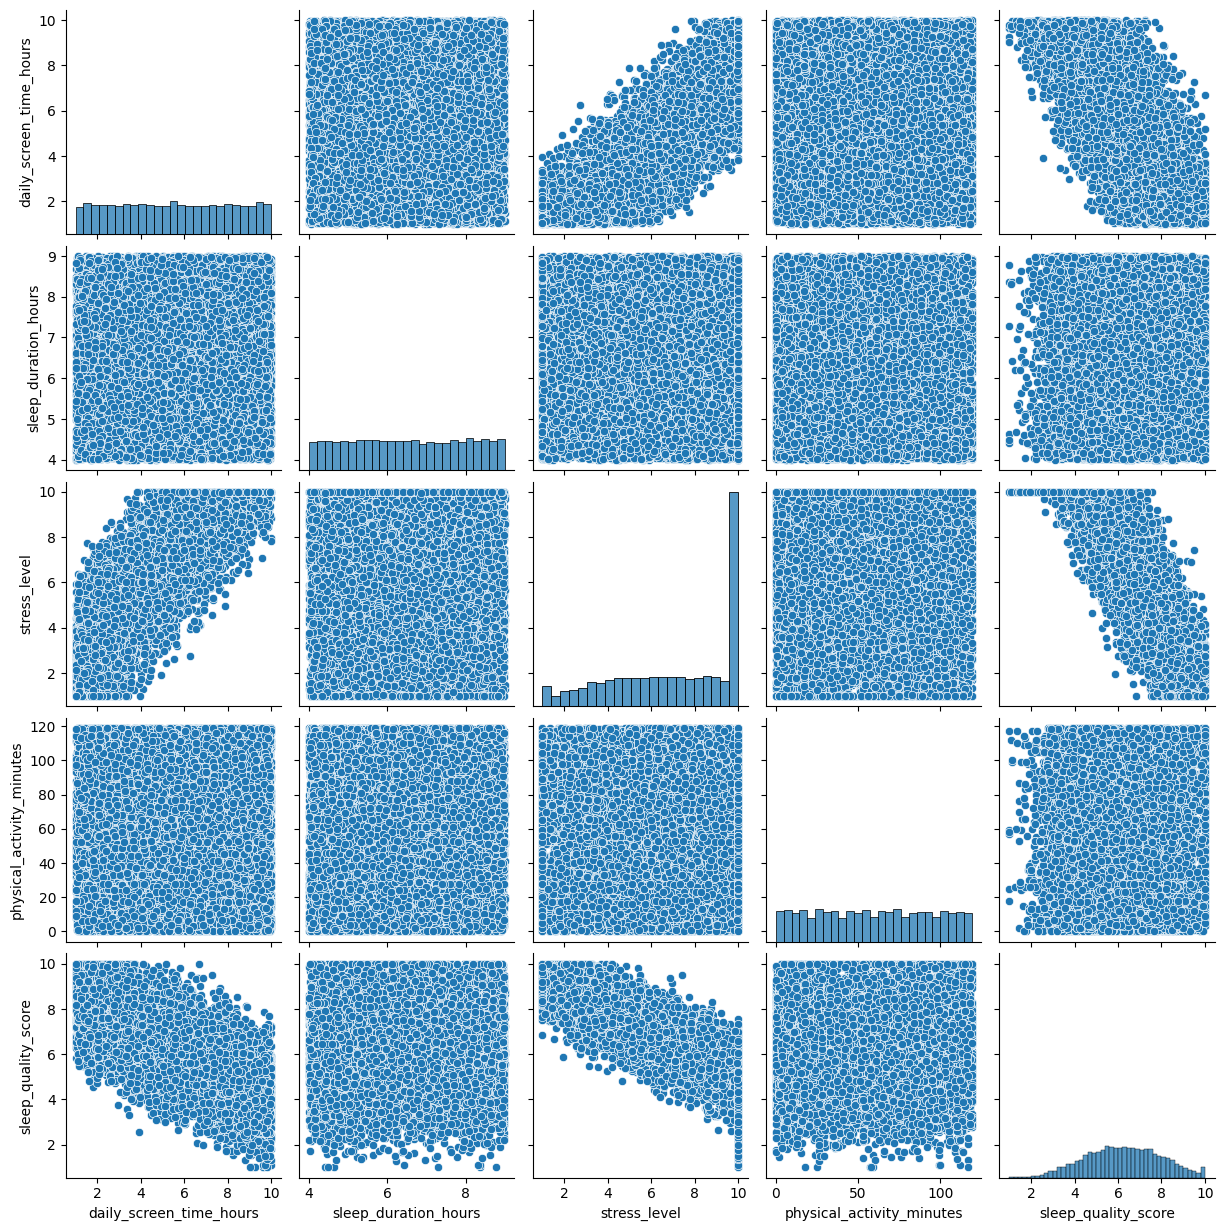

In [21]:
sns.pairplot(
    df[['daily_screen_time_hours',
        'sleep_duration_hours',
        'stress_level',
        'physical_activity_minutes',
        'sleep_quality_score']]
)
plt.show()

## Modeling & Prediction

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['daily_screen_time_hours', 'sleep_quality_score']] 
y = df['stress_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

model= LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test,y_pred)
rmse= np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

print(f"R2 Score: % {r2*100:.2f}")

MAE: 0.82
MSE: 1.05
RMSE: 1.02
R2 Score: % 86.04


In [23]:
X_test_original = scaler.inverse_transform(X_test)

results = pd.DataFrame({
    'Screen Time (Hours)': X_test_original[:, 0],
    'Sleep Quality': X_test_original[:, 1],
    'Real Stress Level': y_test.values,
    'Prediction': y_pred
})

results['Prediction'] = results['Prediction'].round(2)

results['Margin of Error'] = abs(results['Real Stress Level'] - results['Prediction'])

print("Top 10 People Tested from the Dataset")
print(results.head(10))

Top 10 People Tested from the Dataset
   Screen Time (Hours)  Sleep Quality  Real Stress Level  Prediction  \
0                 4.49           8.18               4.74        4.99   
1                 3.29           6.94               6.94        5.21   
2                 8.88           4.11              10.00       10.48   
3                 2.92           6.90               4.29        5.03   
4                 9.59           3.74              10.00       11.15   
5                 8.90           4.46              10.00       10.23   
6                 7.55           3.14              10.00       10.43   
7                 9.53           5.97               8.66        9.49   
8                 3.57           5.41               6.54        6.49   
9                 2.08           8.46               2.53        3.41   

   Margin of Error  
0             0.25  
1             1.73  
2             0.48  
3             0.74  
4             1.15  
5             0.23  
6             0.43  
7

In [24]:
x1_range = np.linspace(X['daily_screen_time_hours'].min(), X['daily_screen_time_hours'].max(), 20)
x2_range = np.linspace(X['sleep_quality_score'].min(), X['sleep_quality_score'].max(), 20)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)


grid_data = np.c_[x1_grid.ravel(), x2_grid.ravel()]
grid_data_scaled = scaler.transform(grid_data) 
y_pr = model.predict(grid_data_scaled)


y_grid = y_pr.reshape(x1_grid.shape)


fig = px.scatter_3d(df, x='daily_screen_time_hours', y='sleep_quality_score', z='stress_level',
                    opacity=0.8, color='stress_level', color_continuous_scale='Viridis')


fig.add_trace(go.Surface(x=x1_range, y=x2_range, z=y_grid, name='Prediction Plane',
                         colorscale='Blues', opacity=0.6, showscale=False))


fig.update_layout(
    title="3D Regression Plane: Stress Prediction Based on Screen Time and Sleep Quality",
    scene=dict(
        xaxis_title='Screen Time (Hours)',
        yaxis_title='Sleep Quality Score',
        zaxis_title='Stress Level'
    ),
    margin=dict(l=0, r=0, b=0, t=40) 
)

fig.show()

/opt/miniconda3/envs/ai_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Trend Analysis:

Effect of Screen Time:
The upward slope of the plane along the "Screen Time" axis demonstrates that as screen time increases,the stress level tends to rise.

Effect of Sleep Quality:
The downward slope along the "Sleep Quality" axis clearly visualizes that as sleep quality increases,the stress level decreases.